<a href="https://colab.research.google.com/github/Art-of-FUgue/Contrapunctus_V_GDS/blob/main/lps_sqc_2026_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Short Course 2026 - Day 3

# Circuit Experimentation on Real Qubits (!)

Welcome back!  Today we are going to experiment with some of the concepts we covered in class, and run circuits on real quantum hardware that is available online.

**Remember to save a copy of this file to your own Google drive before you start working on it.**

# Setup

First we need to install some libraries.  Execute the cell below.  If you get popups asking to restart the session, hit "cancel" until the cell finishes executing.

In [ ]:
!pip install quantuminspire
!pip install qiskit-quantuminspire
!pip install qiskit-aer
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.8/306.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully unins

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 90.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=bfd67a75d79997df6b20bef2775872b209e5755fbeadbce42c7b9d9df4d70cf9
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


If everything installed properly above, you should see a "RESTART SESSION" button.  Go ahead and click on that, then proceed to the next cell.

We will use qiskit again today.

In [ ]:
from qiskit import QuantumCircuit,transpile
from qiskit.visualization import plot_histogram
import qiskit_aer
from qiskit_aer import AerSimulator

import matplotlib.pyplot as plt
%matplotlib inline

# Bell States

Let's build this circuit to make the bell state $|\Phi^+\rangle=\frac{1}{\sqrt{2}}|00\rangle+\frac{1}{\sqrt{2}}|11\rangle$:

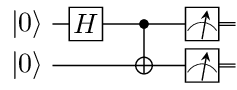

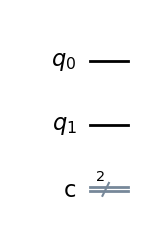

In [ ]:
circ = QuantumCircuit(2, 2)
# fill in the rest of the circuit here
#circ.?(?)
circ.draw('mpl')

# you may find the following gates useful
#circ_u_constant.x(qubit)
#circ_u_constant.y(qubit)
#circ_u_constant.z(qubit)
#circ_u_constant.h(qubit)
#circ_u_constant.s(qubit)
#circ_u_constant.sdg(qubit)
#circ_u_constant.t(qubit)
#circ_u_constant.tdg(qubit)
#circ_u_constant.cx(control, target)
#circ_u_constant.cz(control, target)
#circ_u_constant.ccx(control1, control2, target)
#circ_u_constant.ccz(control1, control2, target)
#circ_u_constant.measure(qubit, cbit)

Now we'll simulate it using a perfect (noiseless) simulator.  Theoretically, we should get the bitstrings 00 and 11 (and only those!) with equal probability.

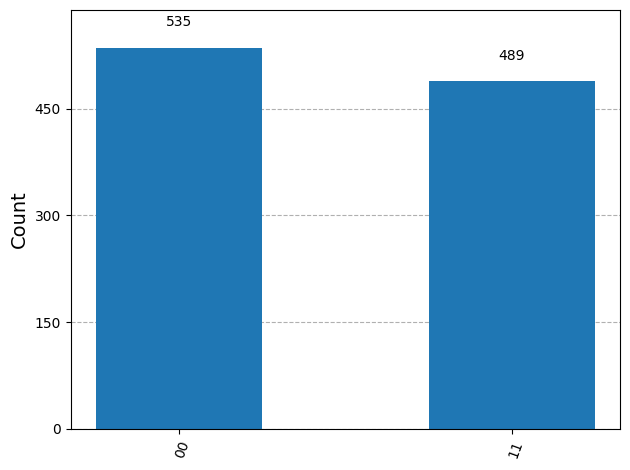

In [ ]:
backend = AerSimulator()

circ_comp = transpile(circ, backend)
job = backend.run(circ_comp, shots=1024)
result = job.result()

plot_histogram(result.get_counts())

As expected, we got about half 00 and half 11.  Now we'll run the circuit on real qubits.  We'll be using the qubit chips hosted by QuTech at TU-Delft, which are available via the Quantum Inspire platform.

First, we need to log in.  The output of the command below should include a URL.  Click on that URL and follow the instructions to authenticate.  Once you've done that, come back here.

In [ ]:
!qi login

/usr/local/lib/python3.12/dist-packages/pydantic_settings/main.py:452: UserWarning: Config key `json_file` is set in model_config but will be ignored because no JsonConfigSettingsSource source is configured. To use this config key, add a JsonConfigSettingsSource source to the settings sources via the settings_customise_sources hook.
  cls._settings_warn_unused_config_keys(sources, cls.model_config)
It is not necessary to specify the protocol in the URL. The protocol will be determined automatically.
Please continue logging in by opening: https://auth.quantum-inspire.com/activate?user_code=PFPD-PMLR in your browser
If promped to verify a code, please confirm it is as follows: PFPD-PMLR
Login successful!
Using member ID 824


Quantum Inspire has several backends available.  Let's see what they are.

In [ ]:
from qiskit_quantuminspire.qi_provider import QIProvider

provider = QIProvider()

# Show all current supported backends:
for backend in provider.backends():
  print(backend, backend.status)

<qiskit_quantuminspire.qi_backend.QIBackend object at 0x7d59d38159a0 (name=QX emulator, id=1)> BackendStatus.IDLE
<qiskit_quantuminspire.qi_backend.QIBackend object at 0x7d59d376dd30 (name=Tuna-5, id=4)> BackendStatus.OFFLINE
<qiskit_quantuminspire.qi_backend.QIBackend object at 0x7d59cf3270b0 (name=Ry emulator, id=5)> BackendStatus.IDLE
<qiskit_quantuminspire.qi_backend.QIBackend object at 0x7d59cec70440 (name=Tuna-9, id=6)> BackendStatus.EXECUTING
<qiskit_quantuminspire.qi_backend.QIBackend object at 0x7d59ceab8b90 (name=Tuna-17, id=7)> BackendStatus.OFFLINE


One of the Tuna chips should be available.  Choose one that is either "IDLE" or "EXECUTING."  (I.e., not "OFFLINE" or "CALIBRATING.")

In [ ]:
backend = provider.get_backend(name='Tuna-17')

Now that we're running our circuits on real hardware, the qubit labels actually matter.  In our circuit above, the two qubits are implicitly labeled "0" and "1."  For reasons we'll get into later, we need to use different labels.  We'll use "0" and "2."

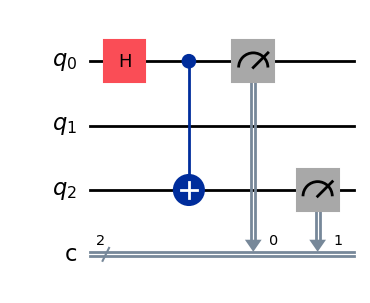

In [ ]:
# quantum circuit with 3 qubits, 2 classical bits
circ = QuantumCircuit(3, 2)
circ.h(0)
circ.cx(0, 2)
# measure qubit 1 and put result in classical bit 0
circ.measure(0, 0)
# measure qubit 2 and put result in classical bit 1
circ.measure(2, 1)
circ.draw('mpl')

There is an extra qubit "1" hanging around---we'll ignore him for now.

Now we can run our job.  It should only take a few seconds to run on the hardware, and maybe another minute to assemble the results, but we'll set a timeout of 600 seconds because the Netherlands is far away :)

Just kidding.  We use a timeout of 600 seconds because that's what the QI folks recommend.

In [ ]:
job = backend.run(circ, shots=1024)
result = job.result(timeout=600)

In [ ]:
print(result)

Result(backend_name='Tuna-9', backend_version='1.0.0', job_id='470556', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 480, '0x1': 22, '0x2': 13, '0x3': 509}), header={'name': 'circuit-228', 'memory_slots': 2}, status=Experiment successful)], date=None, status=Result successful, header=None, qobj_id='', system_messages={})


If you ran into any issues running your circuit, logging into QI, or even creating your QI account, you can instead use this noisy simulator backend.

**If you were unable to run on QI's hardware, set the variable to True and execute the following cell.**

In [ ]:
I_WANT_TO_USE_THE_SIMULATOR_INSTEAD_OF_REAL_QUANTUM_HARDWARE = False

from qiskit_aer.noise import NoiseModel,depolarizing_error,ReadoutError

# we'll build a simple noise model that puts a few percent error on CNOT gates
# and a few percent error on measurement
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ['cx'])
noise_model.add_all_qubit_readout_error(ReadoutError([[0.98,0.02],[0.02,0.98]]))

if I_WANT_TO_USE_THE_SIMULATOR_INSTEAD_OF_REAL_QUANTUM_HARDWARE:
  backend = AerSimulator(noise_model=noise_model)
  job = backend.run(circ, shots=1024)
  result = job.result()

And finally, let's see the results.

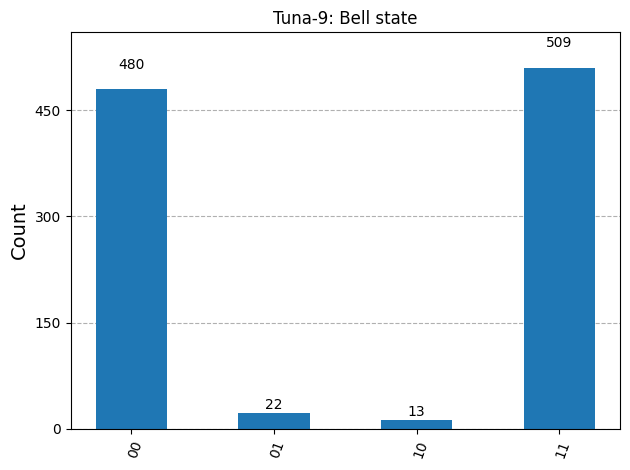

In [ ]:
plot_histogram(result.get_counts(), title=result.backend_name+': Bell state')

Congratulations!  You just created quantum entanglement on real qubits!  

I mean seriously, isn't that freaking AMAZING!!!

We ran on qubit pair 0-2.  Why don't you try with other qubit pairs and see how the results differ?  You can see which qubits are directly connected via the coupling map below.

You can monitor the status of Quantum Inspire's qubit chips, including detailed performance information for each qubit, at the [QI Dashboard](https://dashboard.quantum-inspire.com).

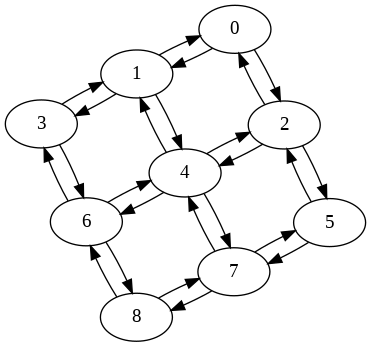

In [ ]:
backend.coupling_map.draw()

Okay, back to the presentation.

# GHZ States

Let's make a 3-qubit GHZ state: $\frac{1}{\sqrt{2}}|000\rangle+\frac{1}{\sqrt{2}}|111\rangle$:

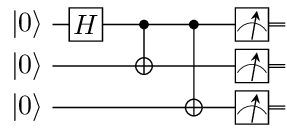

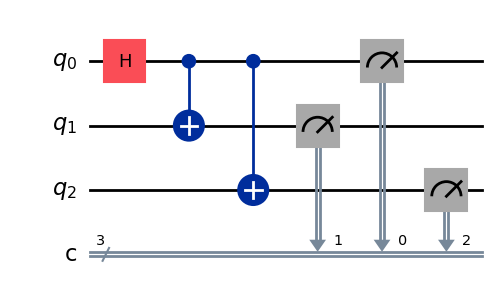

In [ ]:
circ = QuantumCircuit(3, 3)
# fill in the rest of the circuit here
#circ.?(?)
circ.draw('mpl')

Due to constraints on qubit connectivity, we need to transpile our circuit.  That is, we need to apply a transformation on the circuit so it can be executed on the target hardware.

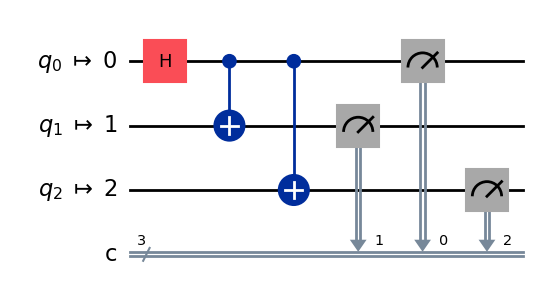

In [ ]:
qubit_priority_list = [0,1,2]
circ_transpiled = transpile(circ, backend, initial_layout=qubit_priority_list[:circ.num_qubits])
circ_transpiled.draw('mpl')

And run it!

In [ ]:
job = backend.run(circ_transpiled, shots=1024)
result = job.result(timeout=600)

In [ ]:
print(result)

Result(backend_name='Tuna-9', backend_version='1.0.0', job_id='470743', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 477, '0x1': 5, '0x2': 28, '0x3': 13, '0x4': 4, '0x5': 23, '0x6': 19, '0x7': 455}), header={'name': 'circuit-171', 'memory_slots': 3}, status=Experiment successful)], date=None, status=Result successful, header=None, qobj_id='', system_messages={})


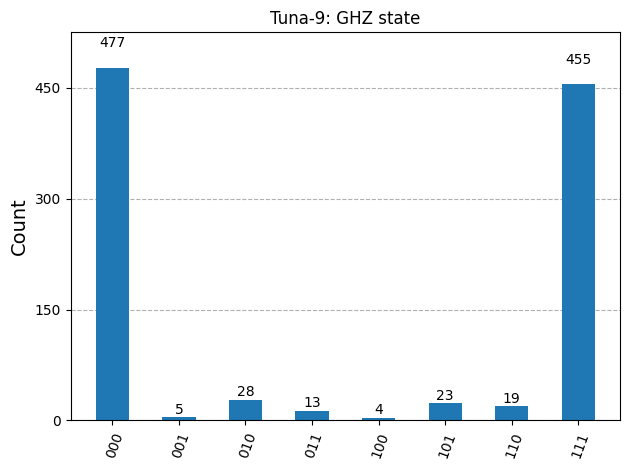

In [ ]:
plot_histogram(result.get_counts(), title=result.backend_name+': GHZ state')

Okay, back to the presentation.

Let's collect some data for GHZ states of size 2 to 17 qubits.

In [ ]:
backend = provider.get_backend(name='Tuna-17')

qubit_priority_list = [0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16,11]
ns = list(range(2,18))
probs = {}

for n in ns:
  print('n={}...'.format(n))
  circ = QuantumCircuit(n, n)
  circ.h(0)
  for i in range(1,n):
    circ.cx(0, i)
  for i in range(n):
    circ.measure(i, i)
  circ_transpiled = transpile(circ, backend, initial_layout=qubit_priority_list[:circ.num_qubits])

  job = backend.run(circ_transpiled, shots=backend.max_shots)

  try:
    result = job.result(timeout=600)
    counts = result.get_counts()
    probs[n] = (counts['0'*n] + counts['1'*n])/backend.max_shots
    print('prob={}'.format(probs[n]))
  except JobTimeoutError:
    print('...job timed out')


n=2...
prob=0.94879150390625
n=3...
prob=0.9224166870117188
n=4...
prob=0.8308334350585938
n=5...
prob=0.7487411499023438
n=6...
prob=0.5887908935546875
n=7...
prob=0.6184616088867188
n=8...
prob=0.5091094970703125
n=9...
prob=0.43392181396484375
n=10...
prob=0.3385162353515625
n=11...
prob=0.31340789794921875
n=12...
prob=0.22754669189453125
n=13...
prob=0.144805908203125
n=14...
prob=0.1316375732421875
n=15...
prob=0.06133270263671875
n=16...
prob=0.09049224853515625
n=17...
prob=0.05976104736328125


And we'll make a pretty picture of the data!

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

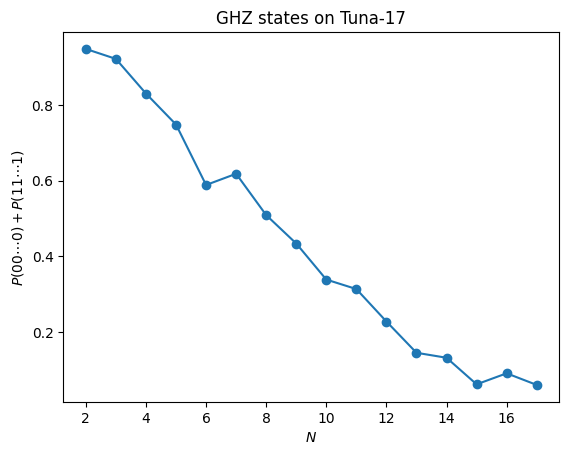

In [ ]:
fig,ax = plt.subplots()
ax.set_title('GHZ states on '+result.backend_name)
ax.set_xlabel('$N$')
ax.set_ylabel('$P(00\\cdots 0)+P(11\\cdots 1)$')
plt.plot(probs.keys(), probs.values(), 'o-')
#plt.show()
plt.savefig('ghz_n_prob.pdf')
from google.colab import files
files.download('ghz_n_prob.pdf')

# Transpilation

The circuits executed above may be different from the abstract circuits we created.  Let's take a look at what actually ran.

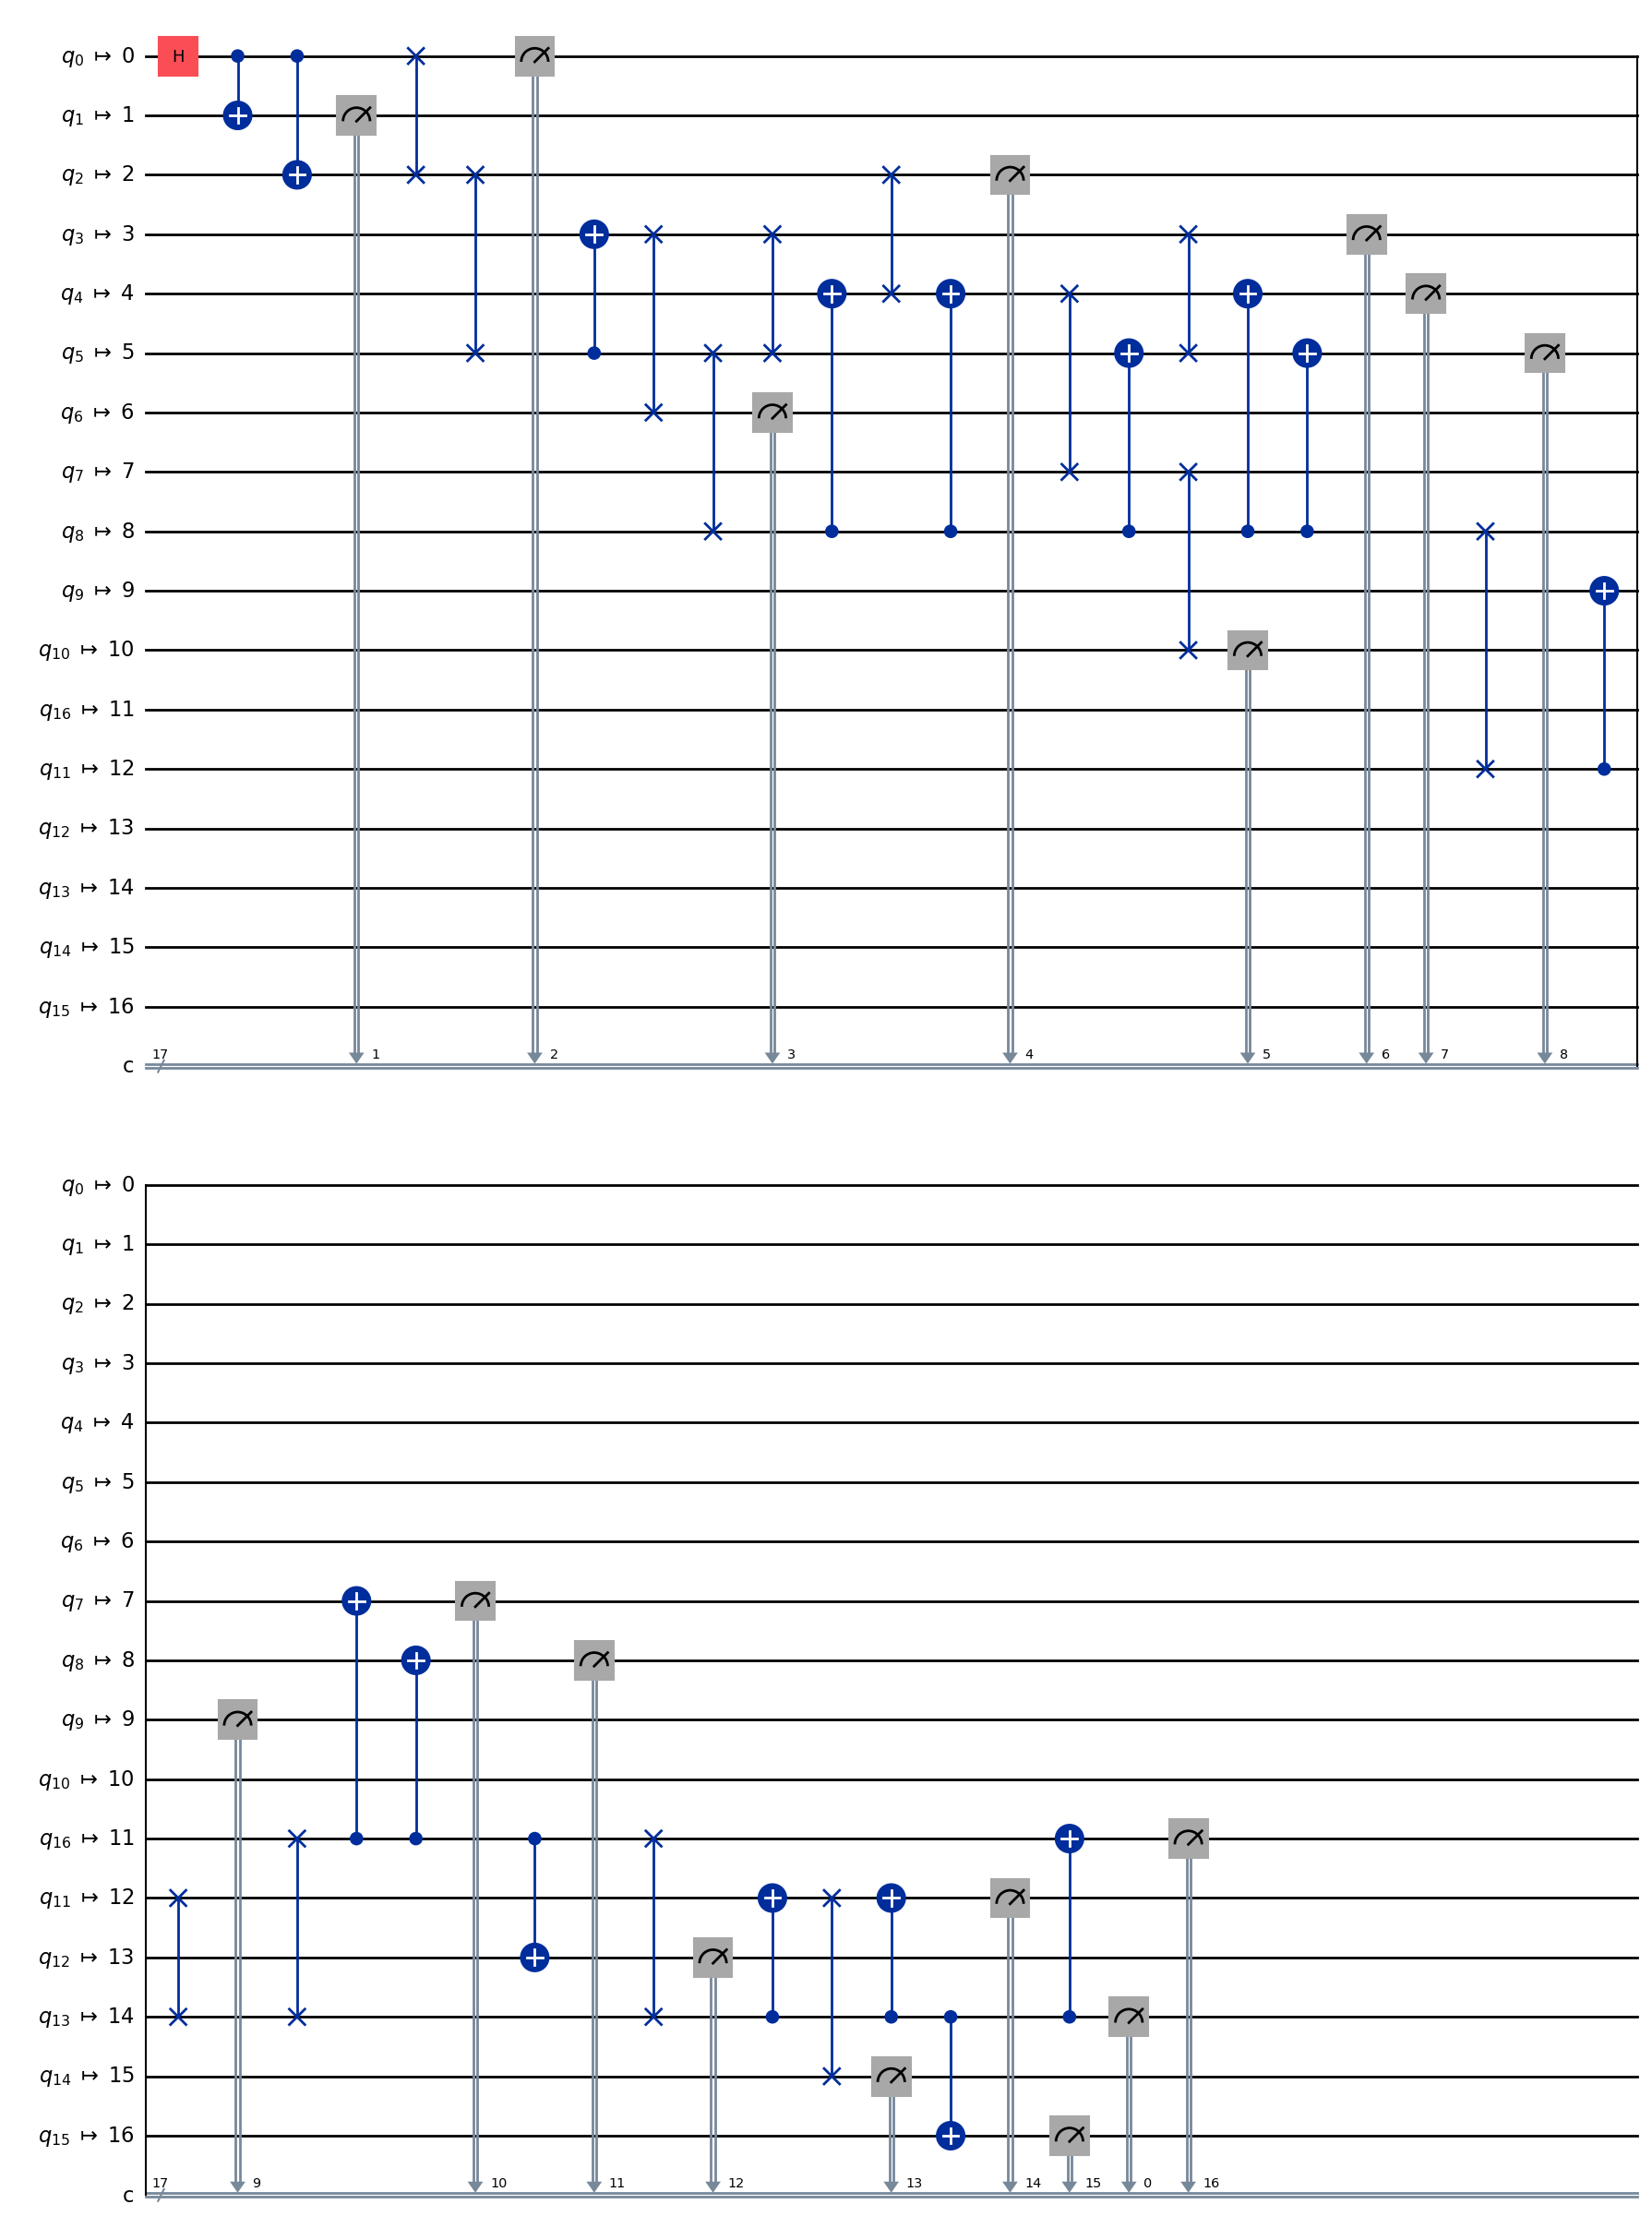

In [ ]:
backend = provider.get_backend(name='Tuna-17')
qubit_priority_list = [0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16,11]

n=17
circ = QuantumCircuit(n, n)
circ.h(0)
for i in range(1,n):
  circ.cx(0, i)
for i in range(n):
  circ.measure(i, i)
circ_transpiled = transpile(circ, backend, initial_layout=qubit_priority_list[:circ.num_qubits])

circ_transpiled.draw('mpl')

The first qubit in our circuit (the one on the top wire) got mapped to qubit number 2 on the hardware.  We may get a clue why that choice was made by looking at the connectivity map for the qubit chip.  This map tells us which qubits can talk to each other---in other words, which pairs of qubits can have two-qubit gates performed on them.

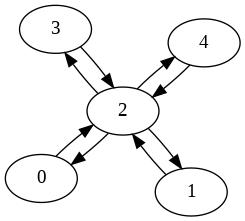

In [ ]:
backend.coupling_map.draw()

In our circuit the first qubit performed CNOT gates with all other qubits.  With this picture it should be clear why that got mapped to qubit number 2 on the hardware.  Qubit 2 can talk to all other qubits on the chip!

# Answers

Bell state prep circuit:

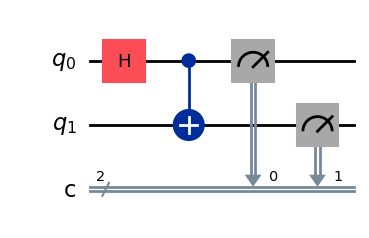

In [ ]:
circ = QuantumCircuit(2, 2)
circ.h(0)
circ.cx(0, 1)
circ.measure(0, 0)
circ.measure(1, 1)
circ.draw('mpl')

GHZ state prep circuit:

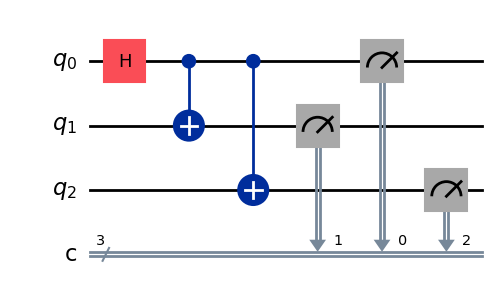

In [ ]:
circ = QuantumCircuit(3, 3)
circ.h(0)
circ.cx(0, 1)
circ.cx(0, 2)
circ.measure(0, 0)
circ.measure(1, 1)
circ.measure(2, 2)
circ.draw('mpl')

# Extra Stuff

Coupling maps for the Tuna chips.

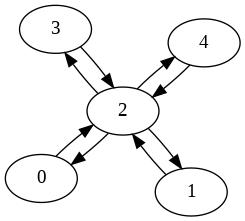

In [ ]:
be = provider.get_backend(name='Tuna-5')
be.coupling_map.draw()

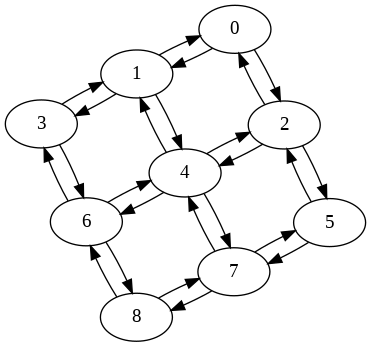

In [ ]:
be = provider.get_backend(name='Tuna-9')
be.coupling_map.draw()

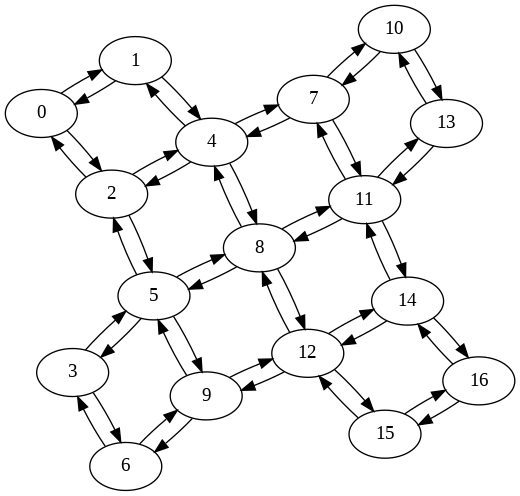

In [ ]:
be = provider.get_backend(name='Tuna-17')
be.coupling_map.draw()